<a href="https://colab.research.google.com/github/edsonportosilva/ElectricCircuits/blob/master/Jupyter%20notebooks/Tutorial%20Sympy%20-%20Python%20para%20Circuitos%20Eletricos%20I%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Tutorial Sympy - Python para Circuitos Elétricos I*

Este notebook contém um guia resumo de como utilizar o pacote **SymPy** do Python para implementar a maior parte das ferramentas matemáticas básicas utilizadas na disciplina de Circuitos Elétricos I.

<h1>Sumário<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Definindo-expressões-matemáticas" data-toc-modified-id="Definindo-expressões-matemáticas-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Definindo expressões matemáticas</a></span></li><li><span><a href="#Calculando-valores-numéricos-de-funções" data-toc-modified-id="Calculando-valores-numéricos-de-funções-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Calculando valores numéricos de funções</a></span></li><li><span><a href="#Arrendondamento-de-valores-numéricos-com-round" data-toc-modified-id="Arrendondamento-de-valores-numéricos-com-round-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Arrendondamento de valores numéricos com <em>round</em></a></span></li><li><span><a href="#Derivadas-utilizando-sp.diff" data-toc-modified-id="Derivadas-utilizando-sp.diff-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Derivadas utilizando <em>sp.diff</em></a></span></li><li><span><a href="#Integrais-definidas-utilizando-sp.integrate" data-toc-modified-id="Integrais-definidas-utilizando-sp.integrate-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Integrais definidas utilizando <em>sp.integrate</em></a></span></li><li><span><a href="#Plotando-gráficos-com-symplot" data-toc-modified-id="Plotando-gráficos-com-symplot-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Plotando gráficos com <em>symplot</em></a></span></li><li><span><a href="#Encontrando-numericamente-um-ponto-de-extremo-(máximo-ou-mínimo)-de-uma-função-com-sp.nsolve" data-toc-modified-id="Encontrando-numericamente-um-ponto-de-extremo-(máximo-ou-mínimo)-de-uma-função-com-sp.nsolve-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Encontrando numericamente um ponto de extremo (máximo ou mínimo) de uma função com <em>sp.nsolve</em></a></span></li><li><span><a href="#Resolvendo-um-sistema-de-equações-lineares-com-sp.solve" data-toc-modified-id="Resolvendo-um-sistema-de-equações-lineares-com-sp.solve-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Resolvendo um sistema de equações lineares com <em>sp.solve</em></a></span></li></ul></div>

In [1]:
if 'google.colab' in str(get_ipython()):    
    ! git clone -b master https://github.com/edsonportosilva/ElectricCircuits
    from os import chdir as cd
    cd('/content/ElectricCircuits/')
    ! pip install -e .
    
import sympy as sp
import numpy as np
from circuit.utils import symdisp, symplot
from IPython.display import Math, Latex, display

### Definindo expressões matemáticas

In [2]:
# definindo variável tempo
t = sp.symbols('t', real=True)

In [3]:
i = sp.exp(-t)
v = t*sp.exp(-t)*sp.cos(t)
p = v*i

symdisp('i(t) = ', i, 'A')
symdisp('v(t) = ', v, 'V')
symdisp('p(t) = ', p, 'W')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

```symdisp``` é uma função customizada (disponível no arquivo ```utils.py``` presente no repositório) para mostrar expressões definidas simbolicamente com SymPy. Para utilizar esta função num notebooks qualquer, faz-se necessário que o arquivo ```utils.py``` esteja no mesmo diretório em que o notebook está salvo.

In [4]:
help(symdisp)

Help on function symdisp in module circuit.utils:

symdisp(expr, var=None, unit=None)
    Display sympy expressions in Latex style.

    Parameters
    ----------
    expr : str
        Expression in latex format.
    var : sympy.core.basic.Basic, optional
        Sympy variable, function, or expression. Default is None.
    unit : str, optional
        String indicating the unit of `var`. Default is None.

    Returns
    -------
    None



### Calculando valores numéricos de funções

In [5]:
symdisp('i(2) = ',  i.evalf(subs={t:2}), 'A')
symdisp('v(2) = ',  v.evalf(subs={t:2}), 'V')
symdisp('p(2) = ',  p.evalf(subs={t:2}), 'W')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

###  Arrendondamento de valores numéricos com *round*

In [6]:
symdisp('i(2) = ',  round(i.evalf(subs={t:2}),3), 'A')
symdisp('v(2) = ',  round(v.evalf(subs={t:2}),3), 'V')
symdisp('p(2) = ',  round(p.evalf(subs={t:2}),3), 'W')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Derivadas utilizando *sp.diff*

In [7]:
didt = sp.diff(i,t)
dvdt = sp.diff(v,t)
dpdt = sp.diff(p,t)

symdisp('\\frac{ d i(t) }{ dt } =', didt)
symdisp('\\frac{ d v(t) }{ dt } =', dvdt)
symdisp('\\frac{ d p(t) }{ dt } =', dpdt)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
d2idt2 = sp.diff(i,t,t)
d2vdt2 = sp.diff(v,t,t)
d2pdt2 = sp.diff(p,t,t)

symdisp('\\frac{ d^2 i(t) }{ dt^2 } =', d2idt2)
symdisp('\\frac{ d^2 v(t) }{ dt^2 } =', d2vdt2)
symdisp('\\frac{ d^2 p(t) }{ dt^2 } =', d2pdt2)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Integrais definidas utilizando *sp.integrate*

In [9]:
int_i = sp.integrate(i, (t, 0, t))
int_v = sp.integrate(v, (t, 0, t))
int_p = sp.integrate(p, (t, 0, t))

symdisp('\\int_{0}^{t} i(u)du =', int_i)
symdisp('\\int_{0}^{t} v(u)du =', int_v)
symdisp('\\int_{0}^{t} p(u)du =', int_p)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [10]:
int_i = sp.integrate(i, (t, 0, 1))
int_v = sp.integrate(v, (t, 0, 1))
int_p = sp.integrate(p, (t, 0, 1))

symdisp('\\int_{0}^{1} i(u)du =', int_i)
symdisp('\\int_{0}^{1} v(u)du =', int_v)
symdisp('\\int_{0}^{1} p(u)du =', int_p)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
symdisp('\\int_{0}^{1} i(u)du =', sp.N(int_i, 2))
symdisp('\\int_{0}^{1} v(u)du =', sp.N(int_v, 2))
symdisp('\\int_{0}^{1} p(u)du =', sp.N(int_p, 2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Plotando gráficos com *symplot*

```symplot``` é uma função customizada (disponível no arquivo ```utils.py``` presente no repositório) para plotar gráficos de funções definidas simbolicamente com SymPy. Para utilizar esta função num notebooks qualquer, faz-se necessário que o arquivo ```utils.py``` esteja no mesmo diretório em que o notebook está salvo.

In [12]:
help(symplot)

Help on function symplot in module circuit.utils:

symplot(
    t,
    F,
    interval,
    funLabel,
    xlabel=' tempo [s]',
    ylabel='',
    figsize=None,
    xfactor=None,
    yfactor=None
)
    Plot sympy expressions.

    Parameters
    ----------
    t : sympy.core.symbol.Symbol
        Time variable.
    F : sympy.core.basic.Basic
        Sympy expression.
    interval : np.array
        Time interval.
    funLabel : str
        Label for the function.
    xlabel : str, optional
        Label for the x-axis. Default is " tempo [s]".
    ylabel : str, optional
        Label for the y-axis. Default is "".
    figsize : tuple, optional
        Figure size. Default is None.
    xfactor : float, optional
        Factor to scale the x-axis. Default is None.
    yfactor : float, optional
        Factor to scale the y-axis. Default is None.

    Returns
    -------
    matplotlib.figure.Figure
        Figure object.



**Exemplos**:

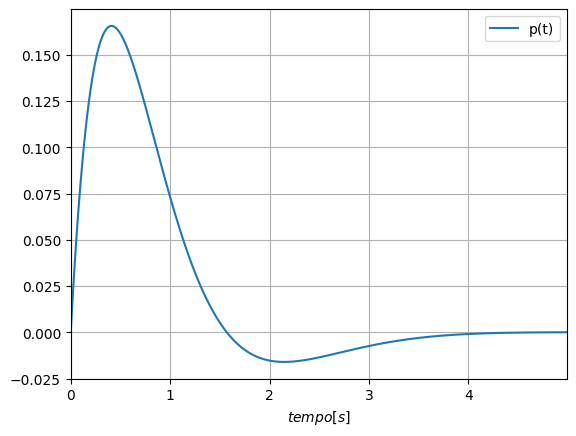

In [13]:
intervalo = np.arange(0, 5, 0.01)

symplot(t, p, intervalo, 'p(t)')

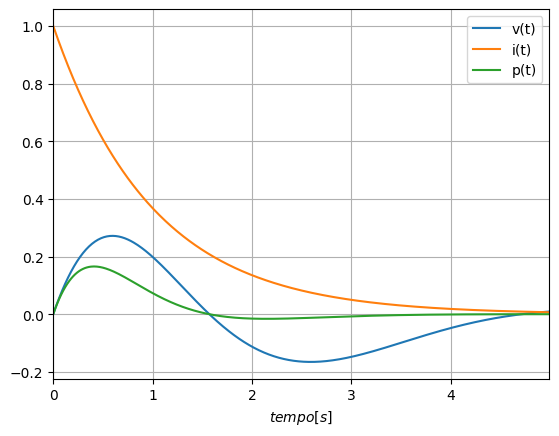

In [14]:
symplot(t, [v, i, p], intervalo, ['v(t)','i(t)','p(t)'])

### Encontrando numericamente um ponto de extremo (máximo ou mínimo) de uma função com *sp.nsolve*

In [15]:
# define a equação dp(t)/dt = 0
eq = sp.Eq(sp.diff(p, t), 0)   

# encontra numericamente o valor de t para o qual dp(t)/dt = 0, no intervalo (0 a 1)
text = sp.nsolve(eq, t, (0 , 1), solver='bisect') # método da bisseção

pext = p.evalf(subs={t:text})  # calcula o valor de p(t) para t=text

d2 = sp.diff(p, t, t)  # calcula derivada segunda de p(t)

sinal_d2 = sp.sign(d2.evalf(subs={t:text})) # verifica sinal da derivada segunda em t=text

if sinal_d2 > 0:
    print('sinal da derivada segunda: positivo (ponto de extremo é um mínimo)')
elif sinal_d2 < 0:
    print('sinal da derivada segunda: negativo (ponto de extremo é um máximo)')
    
symdisp('p(t) = ', p)
symdisp('t_{ext} =', round(text,3))    
symdisp('p_{ext} =', round(pext,3))

sinal da derivada segunda: negativo (ponto de extremo é um máximo)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Resolvendo um sistema de equações lineares com *sp.solve*

In [16]:
# define as N variáveis desconhecidas
x, y, z = sp.symbols('x, y, z')

# define os sistema de N equações
eq1 = sp.Eq(x   + y + z, 10)             
eq2 = sp.Eq(2*x - y + z, 1)  
eq3 = sp.Eq(5*x - 2*y + 3*z, 5)  

print('Sistema de equações lineares:')
display(eq1, eq2, eq3) 

# resolve o sistema
soluc = sp.solve((eq1, eq2, eq3), dict=True)
soluc = soluc[0]

x = soluc[x]
y = soluc[y]
z = soluc[z]

print('Solução do sistema:')
symdisp('x =', x)
symdisp('y =', y)
symdisp('z =', z)

Sistema de equações lineares:


Eq(x + y + z, 10)

Eq(2*x - y + z, 1)

Eq(5*x - 2*y + 3*z, 5)

Solução do sistema:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>